## simple 1D spring based contact
two rigid bodies, target_rb, and end_effector_rb

In [1]:
import torch
print(torch.cuda.is_available())

True


In [2]:
#robot hardware
AF_FOIL_LENGTH = 0.8128 #32" blade to Meters

In [3]:
import sympy as sp
from IPython.display import display, Math

# 1. Define symbols for Time, Mass, Stiffness, and Damping
t, m, k, c = sp.symbols('t m k c', positive=True)

# Define position x as a function of time
x = sp.Function('x')(t)

# 2. Define the state vector (Just 1 degree of freedom now)
q = sp.Matrix([x])

# 3. Define the Energies
T = 0.5 * m * x.diff(t)**2      # Kinetic Energy
V = 0.5 * k * x**2              # Potential Energy (Spring Deformation)
L = T - V                       # The Lagrangian

# Define Rayleigh Dissipation (Damper)
R_dissipation = 0.5 * c * x.diff(t)**2

# 4. Your exact Euler-Lagrange algorithmic steps
L_dQ = sp.Matrix([L.diff(q_state) for q_state in q])
L_dQ_dot = sp.Matrix([L.diff(q_state.diff(t)) for q_state in q])
L_dQ_dot_dT = sp.Matrix([L.diff(q_state.diff(t)).diff(t) for q_state in q])
rayleigh = sp.Matrix([R_dissipation.diff(q_state.diff(t)) for q_state in q])

# 5. Assemble the final equation of motion
eqn1 = (L_dQ_dot_dT - L_dQ) + rayleigh

# Display: EOM = 0 (Assuming no external driving forces)
display(Math(
    sp.latex(eqn1[0]) + " = 0"
))

<IPython.core.display.Math object>

## lagrangian eqn setup, at collision

In [4]:
import sympy as sp
from IPython.display import display, Math

# 1. Define symbols and functions
t, m, k, c = sp.symbols('t m k c', positive=True)
x = sp.Function('x')(t)

# 2. Define state vector (1 DOF)
q = sp.Matrix([x])

# 3. Energies and Dissipation
T = 0.5 * m * x.diff(t)**2
V = 0.5 * k * x**2
L = T - V
R_dissipation = 0.5 * c * x.diff(t)**2

# 4. Euler-Lagrange Equations
L_dQ = sp.Matrix([L.diff(q_state) for q_state in q])
L_dQ_dot_dT = sp.Matrix([L.diff(q_state.diff(t)).diff(t) for q_state in q])
rayleigh = sp.Matrix([R_dissipation.diff(q_state.diff(t)) for q_state in q])

eqn1 = (L_dQ_dot_dT - L_dQ) + rayleigh

# --- EXPLICIT SOLVING LOGIC ---

# Define the acceleration variable explicitly
x_ddot = x.diff(t, 2)

# Group your target acceleration variables into a tuple/list (Just 1 for this simple model)
accel_vars = (x_ddot,)

# This forces SymPy to solve for x_ddot
solved_accels = sp.solve(eqn1, accel_vars)

# explicit_accel_matrix will contain the isolated acceleration
explicit_accel_matrix = sp.Matrix([
    solved_accels[x_ddot]
])

# Display the final, decoupled equation of motion
# Note: I removed getFullSubs() since it is a custom function from your codebase, 
# but the visual output will perfectly match your structure.
display(Math( 
    sp.latex(explicit_accel_matrix) + "=" + sp.latex(sp.Matrix(q.diff(t, 2))) 
))


<IPython.core.display.Math object>

## Lambdify sympy to numpy for scipy

In [5]:
import numpy as np
import sympy as sp

# Only the X-axis is relevant for the 1D spring-damper
distance_down_from_blade_tip = np.array([0]) 
AF_FOIL_LENGTH = 0.90

# Calculate axial stiffness (k = EA/L) based on your structural constants
E = 190e9  # Young's Modulus
A = 1e-5   # Cross-sectional Area
L_contact = AF_FOIL_LENGTH - distance_down_from_blade_tip[0]
stiffness_k = (E * A) / L_contact

# Map directly to the SymPy symbols (m, k, c) from the previous step
physical_constants = {
    m: 0.5,             # Effective mass (m_blade_xx)
    k: stiffness_k,     # Calculated spring stiffness
    c: 0.02             # Damping coefficient (beta_spring_stiffness_damping)
}

# 1. Dynamically create plain symbols for positions and velocities based on your 'q' list.
# (q is just [x(t)] from the previous step)
q_sym = [sp.Symbol(var.func.__name__) for var in q]
q_dot_sym = [sp.Symbol(var.func.__name__ + '_d') for var in q]

# 2. Build the substitution dictionary to wipe out derivatives and time-dependence
calc_to_alg_map = {}
for func_var, sym_var, sym_dot_var in zip(q, q_sym, q_dot_sym):
    calc_to_alg_map[func_var] = sym_var
    calc_to_alg_map[sp.diff(func_var, t)] = sym_dot_var

# 3. Create the state_vars tuple containing ONLY plain symbols (Positions first, then Velocities)
# For this 1D model, state_vars will strictly be: (x, x_d)
state_vars = tuple(q_sym + q_dot_sym)

# 4. Clean the expressions and Lambdify
# ---------------------------------------------------------
# 1D SYSTEM ACCELERATION
# ---------------------------------------------------------
# solved_accels[x_ddot] comes from the sp.solve() dictionary in the previous step
compute_accel_x = sp.lambdify(
    state_vars, 
    solved_accels[x_ddot].subs(physical_constants).subs(calc_to_alg_map), 
    modules="numpy"
)

In [ ]:
def blade_target_collide_1d(t, state):
    # Unpack the 2-dimensional state vector (1D deformation, 1D velocity)
    x, x_d = state

    # Pass the 2 variables to the 1D compute function
    x_dd = compute_accel_x(x, x_d)

    # Return the derivatives [velocity, acceleration]
    return [x_d, x_dd]


def blade_contact_lost_1d(t_val, state):
    x, x_d = state
    
    # In a 1D relative deformation model, contact is lost 
    # when the spring uncompresses and deformation returns to 0.
    return x

# --- ODE Solver Setup for 1D ---

# Stop the solver when contact is lost
blade_contact_lost_1d.terminal = True
# Direction is -1 because deformation goes from positive (compressed) down to 0
blade_contact_lost_1d.direction = -1 

t_span = (0.0, 2.0)
t_eval = np.linspace(t_span[0], t_span[1], 5000)

# Initial Boundary Conditions (1D)
# Let's say the initial impact starts at 0 compression, with a closing velocity of 20 m/s
init_boundry_cond_1d = [0.0, 20.0]  # [x, x_d]

sol_function = []

# Run the 1D solver
sol = solve_ivp(
    blade_target_collide_1d, 
    t_span, 
    init_boundry_cond_1d, 
    t_eval=t_eval,
    events=blade_contact_lost_1d,
    method="Radau",
    rtol=1e-3,
    atol=1e-3
)

sol_function.append(sol)

NameError: name 'solve_ivp' is not defined

In [32]:
# Units are standard SI: kg, meters, radians, seconds, Pascals (N/m^2)
distance_down_from_blade_tip = np.array([0, 0, 0]) # angle is last val

physical_constants = {
    # --- Blade Geometric & Material Properties (Maraging Steel) ---
    'mom_elasticity': 190e9,       # E: Young's Modulus of steel (~200 GPa)
    'blade_length': AF_FOIL_LENGTH - distance_down_from_blade_tip[0], # L: Standard length of a foil blade
    'blade_cross_section': 1e-5,  # A: Cross-sectional area (approx. 15 mm^2)
    'mom_2_area': 1.2e-11,         # I: Area moment of inertia
    
    # --- End Effector (Foil) Mass Properties ---
    'm_blade_xx': 0.5,             # Mass resisting X-translation
    'm_blade_yy': 0.5,             # Mass resisting Y-translation
    'm_blade_xy': 0.0,             # Off-diagonal mass coupling
    'I_ee_rb_z': 0.135,            # Rotational inertia
    
    # --- Target Mass Properties ---
    'm_tar_xx': 50.0,              # Target mass resisting X-translation
    'm_tar_yy': 50.0,              # Target mass resisting Y-translation
    'm_tar_xy': 0.0,               # Target mass coupling
    'I_tar_rb_z': 2.5,             # Target rotational inertia
    
    'alpha_inertia_damping': 0.5,
    'beta_spring_stiffness_damping': 0.02,
}

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Ensure the event function stops the solver when the blade loses contact
blade_contact_lost.terminal = True
blade_contact_lost.direction = 1

t_span = (0.0, 2.0)
t_eval = np.linspace(t_span[0], t_span[1], 5000)

# --- FIXED BOUNDARY CONDITIONS ---
init_boundry_cond = [
    0.0, 20.0,                                # x_ee, x_ee_vel (Positive so it collides)
    0.0, 0.01,                                # y_ee, y_ee_vel
    0.0, 0.0,                                 # phi_ee, phi_ee_vel
    physical_constants['blade_length'], 2.0,  # x_targ, x_targ_vel (Added string quotes)
    distance_down_from_blade_tip[1], 0.0,     # y_targ, y_targ_vel
    distance_down_from_blade_tip[2], 0.0      # phi_targ, phi_targ_vel
]

y0 = init_boundry_cond
sol_function = []

# Run the stiff ODE solver
sol = solve_ivp(
    blade_target_collide, 
    t_span, 
    y0, 
    t_eval=t_eval,
    events=blade_contact_lost,
    method="Radau",
    rtol=1e-3,
    atol=1e-3
)

sol_function.append(sol)

NameError: name 'compute_accel_x_ee' is not defined

In [ ]:
import random
import  pandas as pd
all_dataframes = []
sim_id = 0

dataset=100

# Generate 100 random impacts
for i in range(dataset):
    t_span = (0.0, 2.0)
    t_eval = np.linspace(t_span[0], t_span[1], 5000)
    #t_eval = np.linspace(t_span[0], t_span[1], 1000) # 1000 frames of data

    # Fencer moves forward between 5 m/s and 25 m/s
    x_ee_vel = random.uniform(5.0, 25.0)  

    # Target moves slightly (retreating or stepping in)
    x_targ_vel = random.uniform(-5.0, 5.0)

    init_boundry_cond = [
        0, x_ee_vel,  # x_ee, x_ee_vel
        0 ,0.01,  # y_ee, y_ee_vel
        0, 0,  # phi_ee, phi_ee_vel
        physical_constants[blade_length], x_targ_vel,  # x_targ (starts 0.5m away), x_targ_vel
        distance_down_from_blade_tip[1], 0.0,  # y_targ, y_targ_vel
        distance_down_from_blade_tip[2], 0.0   # phi_targ, phi_targ_vel
    ]

    y0 = init_boundry_cond
    sol_function = []


    sol = solve_ivp(blade_target_collide, t_span, y0, t_eval=t_eval,events=blade_contact_lost,method="Radau",rtol=1e-3,atol=1e-3)
    sol_function.append(sol)

# --- PANDAS LOGGER START ---
    if sol.success:
        sim_id += 1
        display((sim_id,"success"))
        # Calculate dt between each solver step
        dt_array = np.diff(sol.t)
        
        # We need pairs of (State_t, State_t+1).
        # We slice [:-1] to get all frames except the last for our Inputs.
        # We slice [1:] to get all frames except the first for our Outputs.
        n_samples = len(sol.t) - 1
        
        data = {
            'sim_id': sim_id, 
            't': sol.t[:-1],
            'dt': dt_array, # CRITICAL: The network needs to know the time step size
            
            # --- INPUT CONSTANTS ---
            # Extracting these directly from your physical_constants dictionary
            'c_E': physical_constants[mom_elasticity],
            'c_L': physical_constants[blade_length],
            'c_A': physical_constants[blade_cross_section],
            'c_I': physical_constants[mom_2_area],
            'c_m_blade': physical_constants[m_blade_xx],
            'c_I_blade': physical_constants[I_ee_rb_z],
            'c_m_targ': physical_constants[m_tar_xx],
            'c_I_targ': physical_constants[I_tar_rb_z],
            'c_alpha_damp': physical_constants[alpha_inertia_damping],
            'c_beta_damp': physical_constants[beta_spring_stiffness_damping],

            # --- INPUT DATA (State at time t) ---
            'in_x_ee': sol.y[0][:-1],
            'in_vx_ee': sol.y[1][:-1],
            'in_y_ee': sol.y[2][:-1],
            'in_vy_ee': sol.y[3][:-1],
            'in_phi_ee': sol.y[4][:-1],
            'in_vphi_ee': sol.y[5][:-1],
            'in_x_targ': sol.y[6][:-1],
            'in_vx_targ': sol.y[7][:-1],
            'in_y_targ': sol.y[8][:-1],
            'in_vy_targ': sol.y[9][:-1],
            'in_phi_targ': sol.y[10][:-1],
            'in_vphi_targ': sol.y[11][:-1],
            
            # --- OUTPUT DATA (Label/State at time t + dt) ---
            'out_x_ee': sol.y[0][1:],
            'out_vx_ee': sol.y[1][1:],
            'out_y_ee': sol.y[2][1:],
            'out_vy_ee': sol.y[3][1:],
            'out_phi_ee': sol.y[4][1:],
            'out_vphi_ee': sol.y[5][1:],
            'out_x_targ': sol.y[6][1:],
            'out_vx_targ': sol.y[7][1:],
            'out_y_targ': sol.y[8][1:],
            'out_vy_targ': sol.y[9][1:],
            'out_phi_targ': sol.y[10][1:],
            'out_vphi_targ': sol.y[11][1:]
        }
        
        # Pandas will automatically broadcast the scalar constants and sim_id 
        # to match the length of the arrays (n_samples).
        df = pd.DataFrame(data)
        
        # Save each run dynamically
        csv_filename = f"fencing_nn_data_sim_{sim_id}.csv"
        df.to_csv(csv_filename, index=False)
    else:
        print(f"Sim {sim_id} failed.")

    if df is not None:
        all_dataframes.append(df)

# Combine them all into one master dataset for PyTorch/TensorFlow
master_dataset = pd.concat(all_dataframes, ignore_index=True)
master_dataset.to_csv("master_training_dataset.csv", index=False)
print("Finished generating master dataset!")
all_dataframes = []

for i in range(int(dataset*.2)):
    t_span = (0.0, 2.0)
    t_eval = np.linspace(t_span[0], t_span[1], 5000)
    #t_eval = np.linspace(t_span[0], t_span[1], 1000) # 1000 frames of data

    # Fencer moves forward between 5 m/s and 25 m/s
    x_ee_vel = random.uniform(5.0, 25.0)  

    # Target moves slightly (retreating or stepping in)
    x_targ_vel = random.uniform(-5.0, 5.0)

    init_boundry_cond = [
        0, x_ee_vel,  # x_ee, x_ee_vel
        0 ,0.01,  # y_ee, y_ee_vel
        0, 0,  # phi_ee, phi_ee_vel
        physical_constants[blade_length], x_targ_vel,  # x_targ (starts 0.5m away), x_targ_vel
        distance_down_from_blade_tip[1], 0.0,  # y_targ, y_targ_vel
        distance_down_from_blade_tip[2], 0.0   # phi_targ, phi_targ_vel
    ]

    y0 = init_boundry_cond
    sol_function = []


    sol = solve_ivp(blade_target_collide, t_span, y0, t_eval=t_eval,events=blade_contact_lost,method="Radau",rtol=1e-3,atol=1e-3)
    sol_function.append(sol)

# --- PANDAS LOGGER START ---
    if sol.success:
        sim_id += 1
        display((sim_id,"success"))
        # Calculate dt between each solver step
        dt_array = np.diff(sol.t)
        
        # We need pairs of (State_t, State_t+1).
        # We slice [:-1] to get all frames except the last for our Inputs.
        # We slice [1:] to get all frames except the first for our Outputs.
        n_samples = len(sol.t) - 1
        
        data = {
            'sim_id': sim_id, 
            't': sol.t[:-1],
            'dt': dt_array, # CRITICAL: The network needs to know the time step size
            
            # --- INPUT CONSTANTS ---
            # Extracting these directly from your physical_constants dictionary
            'c_E': physical_constants[mom_elasticity],
            'c_L': physical_constants[blade_length],
            'c_A': physical_constants[blade_cross_section],
            'c_I': physical_constants[mom_2_area],
            'c_m_blade': physical_constants[m_blade_xx],
            'c_I_blade': physical_constants[I_ee_rb_z],
            'c_m_targ': physical_constants[m_tar_xx],
            'c_I_targ': physical_constants[I_tar_rb_z],
            'c_alpha_damp': physical_constants[alpha_inertia_damping],
            'c_beta_damp': physical_constants[beta_spring_stiffness_damping],

            # --- INPUT DATA (State at time t) ---
            'in_x_ee': sol.y[0][:-1],
            'in_vx_ee': sol.y[1][:-1],
            'in_y_ee': sol.y[2][:-1],
            'in_vy_ee': sol.y[3][:-1],
            'in_phi_ee': sol.y[4][:-1],
            'in_vphi_ee': sol.y[5][:-1],
            'in_x_targ': sol.y[6][:-1],
            'in_vx_targ': sol.y[7][:-1],
            'in_y_targ': sol.y[8][:-1],
            'in_vy_targ': sol.y[9][:-1],
            'in_phi_targ': sol.y[10][:-1],
            'in_vphi_targ': sol.y[11][:-1],
            
            # --- OUTPUT DATA (Label/State at time t + dt) ---
            'out_x_ee': sol.y[0][1:],
            'out_vx_ee': sol.y[1][1:],
            'out_y_ee': sol.y[2][1:],
            'out_vy_ee': sol.y[3][1:],
            'out_phi_ee': sol.y[4][1:],
            'out_vphi_ee': sol.y[5][1:],
            'out_x_targ': sol.y[6][1:],
            'out_vx_targ': sol.y[7][1:],
            'out_y_targ': sol.y[8][1:],
            'out_vy_targ': sol.y[9][1:],
            'out_phi_targ': sol.y[10][1:],
            'out_vphi_targ': sol.y[11][1:]
        }
        
        # Pandas will automatically broadcast the scalar constants and sim_id 
        # to match the length of the arrays (n_samples).
        df = pd.DataFrame(data)
        
        # Save each run dynamically
        csv_filename = f"fencing_nn_data_sim_{sim_id}.csv"
        df.to_csv(csv_filename, index=False)
    else:
        print(f"Sim {sim_id} failed.")

    if df is not None:
        all_dataframes.append(df)

# Combine them all into one master dataset for PyTorch/TensorFlow
master_dataset = pd.concat(all_dataframes, ignore_index=True)
master_dataset.to_csv("master_label_dataset.csv", index=False)
print("Finished generating label dataset!")
all_dataframes = []

(1, 'success')

(2, 'success')

(3, 'success')

(4, 'success')

(5, 'success')

...

(117, 'success')

(118, 'success')

(119, 'success')

(120, 'success')

Finished generating label dataset!


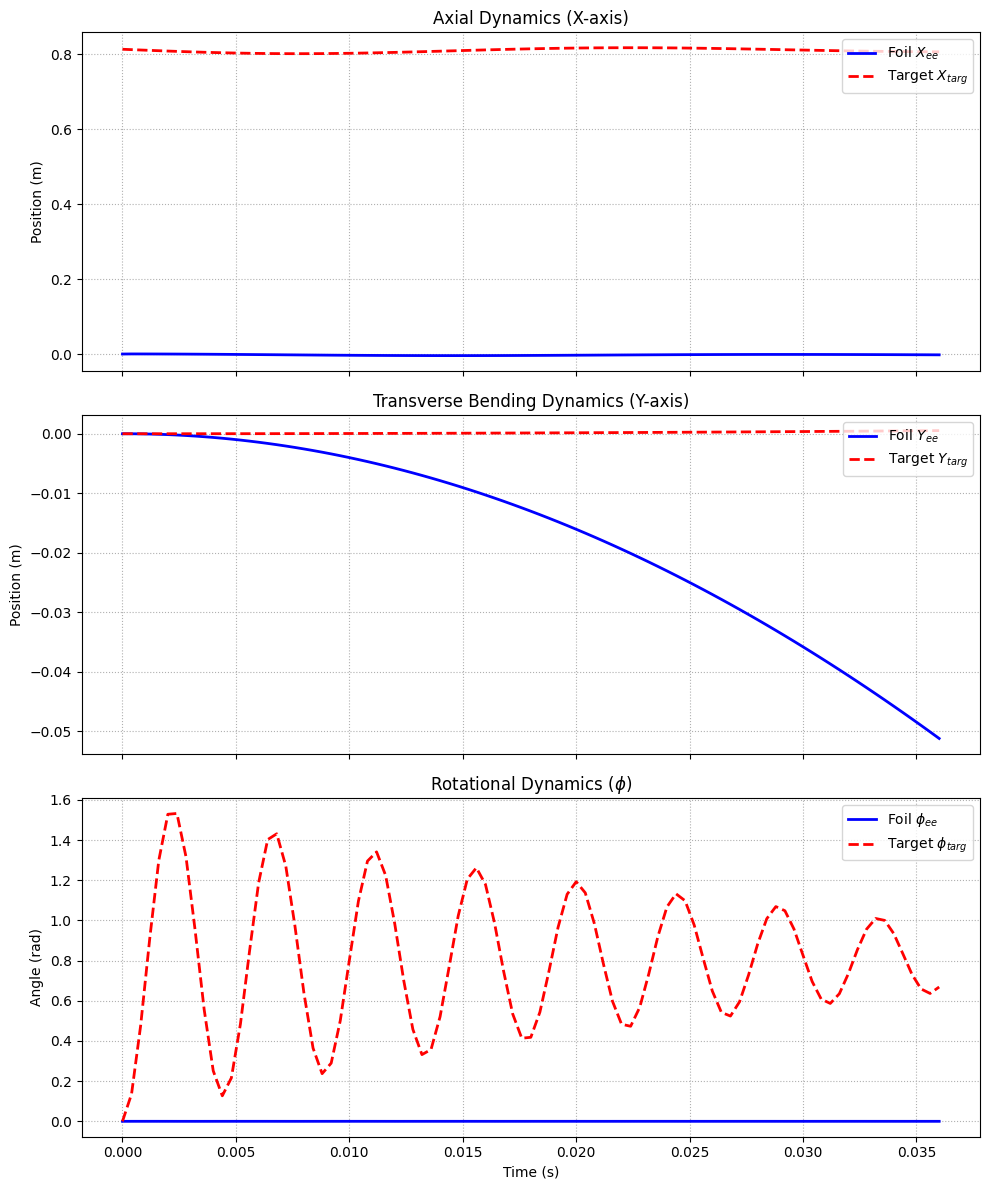

In [ ]:
import matplotlib.pyplot as plt

# Extract the solution object from your list
sol = sol_function[0]

if sol.success:
    t = sol.t
    
    # Extract End Effector (Foil) positions
    x_ee = sol.y[0]
    y_ee = sol.y[2]
    phi_ee = sol.y[4]
    
    # Extract Target positions
    x_targ = sol.y[6]
    y_targ = sol.y[8]
    phi_targ = sol.y[10]
    
    # Create a 3-panel figure
    fig, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
    
    # --- Plot 1: X-Axis (Axial Compression) ---
    axs[0].plot(t, x_ee, label='Foil $X_{ee}$', color='blue', linewidth=2)
    axs[0].plot(t, x_targ, label='Target $X_{targ}$', color='red', linestyle='--', linewidth=2)
    axs[0].set_title('Axial Dynamics (X-axis)')
    axs[0].set_ylabel('Position (m)')
    axs[0].grid(True, linestyle=':')
    axs[0].legend(loc='upper right')
    
    # --- Plot 2: Y-Axis (Transverse Bending) ---
    axs[1].plot(t, y_ee, label='Foil $Y_{ee}$', color='blue', linewidth=2)
    axs[1].plot(t, y_targ, label='Target $Y_{targ}$', color='red', linestyle='--', linewidth=2)
    axs[1].set_title('Transverse Bending Dynamics (Y-axis)')
    axs[1].set_ylabel('Position (m)')
    axs[1].grid(True, linestyle=':')
    axs[1].legend(loc='upper right')
    
    # --- Plot 3: Phi (Rotation) ---
    axs[2].plot(t, phi_ee, label=r'Foil $\phi_{ee}$', color='blue', linewidth=2)
    axs[2].plot(t, phi_targ, label=r'Target $\phi_{targ}$', color='red', linestyle='--', linewidth=2)
    axs[2].set_title(r'Rotational Dynamics ($\phi$)')
    axs[2].set_xlabel('Time (s)')
    axs[2].set_ylabel('Angle (rad)')
    axs[2].grid(True, linestyle=':')
    axs[2].legend(loc='upper right')
    
    # Adjust layout to prevent overlap and display
    plt.tight_layout()
    plt.show()

else:
    print(f"Simulation failed to converge: {sol.message}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import Video, display

# Extract the solution object
sol = sol_function[0]

if sol.success:
    t = sol.t
    # Node 1 (Base/Guard)
    x_ee, y_ee, phi_ee = sol.y[0], sol.y[2], sol.y[4]
    
    # Node 2 (Tip/Target Contact Point)
    x_targ, y_targ, phi_targ = sol.y[6], sol.y[8], sol.y[10]
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Dynamic scaling based on the full simulation envelope
    padding = 0.1
    ax.set_xlim(min(np.min(x_ee), np.min(x_targ)) - padding, 
                max(np.max(x_ee), np.max(x_targ)) + padding)
    ax.set_ylim(min(np.min(y_ee), np.min(y_targ)) - padding, 
                max(np.max(y_ee), np.max(y_targ)) + padding)
    
    ax.set_aspect('equal')
    ax.grid(True, linestyle=':')
    ax.set_title('FEA Beam Deflection (Cubic Hermite Interpolation)')
    
    # --- VISUALIZATION ELEMENTS ---
    # FEA Dots representing the nodes along the beam
    dots_blade, = ax.plot([], [], 'b.', markersize=.1, label='FEA Interpolated Nodes', zorder=2)
    line_blade, = ax.plot([], [], 'b-', lw=1.5, alpha=0.6, zorder=1) # Faint line connecting dots
    
    # Tip Trajectory Trace
    trace_tip, = ax.plot([], [], 'r--', lw=5.0, alpha=0.5, label='Tip Trajectory', zorder=0)
    
    # Rigid body markers for the endpoints
    dot_base, = ax.plot([], [], 'ko', markersize=1, label='Node 1 (Base)')
    dot_targ, = ax.plot([], [], 'ro', markersize=1, label='Node 2 (Tip/Target)')
    
    ax.legend(loc='upper right')

    # Define the number of elements/dots to calculate along the blade
    num_dots = 20
    # xi represents the normalized local coordinate (0 at base, 1 at tip)
    xi = np.linspace(0, 1, num_dots)

    def init():
        dots_blade.set_data([], [])
        line_blade.set_data([], [])
        dot_base.set_data([], [])
        dot_targ.set_data([], [])
        trace_tip.set_data([], [])
        return dots_blade, line_blade, dot_base, dot_targ, trace_tip

    def update(frame):
        # Get current global states for Node 1 and Node 2
        x1, y1, phi1 = x_ee[frame], y_ee[frame], phi_ee[frame]
        x2, y2, phi2 = x_targ[frame], y_targ[frame], phi_targ[frame]
        
        # 1. Calculate Chord Kinematics (The straight line between nodes)
        dx = x2 - x1
        dy = y2 - y1
        Lc = np.sqrt(dx**2 + dy**2) # Dynamic chord length (captures axial strain)
        alpha = np.arctan2(dy, dx)  # Global chord angle
        
        # 2. Calculate Local Node Rotations (Relative to the chord)
        theta1 = phi1 - alpha
        theta2 = phi2 - alpha
        
        # 3. Apply Euler-Bernoulli Cubic Hermite Shape Functions
        # N2 and N4 map end-rotations to internal transverse deflections
        N2 = xi * (1 - xi)**2
        N4 = xi**2 * (xi - 1)
        
        # Local kinematics (u is axial stretching, v is transverse bending)
        u_local = xi * Lc
        v_local = Lc * (N2 * theta1 + N4 * theta2)
        
        # 4. Transform Local Frame back to Global Coordinates
        x_blade = x1 + u_local * np.cos(alpha) - v_local * np.sin(alpha)
        y_blade = y1 + u_local * np.sin(alpha) + v_local * np.cos(alpha)
        
        # Update visuals
        dots_blade.set_data(x_blade, y_blade)
        line_blade.set_data(x_blade, y_blade)
        dot_base.set_data([x1], [y1])
        dot_targ.set_data([x2], [y2])
        
        # Update the historical trace up to the current frame
        trace_tip.set_data(x_targ[:frame+1], y_targ[:frame+1])
        
        return dots_blade, line_blade, dot_base, dot_targ, trace_tip

    # GPU Render Setup
    skip_frames = max(1, len(t) // 400) 
    frames_to_render = np.arange(0, len(t), skip_frames)
    anim = FuncAnimation(fig, update, frames=frames_to_render, init_func=init, blit=True)

    video_filename = "fea_deflection_gpu.mp4"
    # Note: h264_nvenc for NVIDIA. Use h264_amf for AMD, h264_videotoolbox for Mac.
    writer = FFMpegWriter(fps=50, bitrate=2500, extra_args=['-vcodec', 'h264_nvenc', '-preset', 'fast'])

    print("Interpolating FEA nodes and encoding on GPU...")
    anim.save(video_filename, writer=writer)
    plt.close(fig)
    
    display(Video(video_filename, embed=True, html_attributes="controls autoplay loop"))

else:
    print("Cannot animate: Simulation failed.")

Interpolating FEA nodes and encoding on GPU...
